<a href="https://colab.research.google.com/github/Fixer1313/DA_case5/blob/main/notebooks/01_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Исследование факторов, влияющих на длительность госпитализации, диагнозы и затраты в медицинских учреждениях. Предварительная обработка

##Импорт библиотек и загрузка датасета

In [ ]:
import pandas as pd

In [ ]:
url = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/hospital%20data%20analysis.csv"

In [ ]:
df = pd.read_csv(url)
df.head()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4


##Предварительный обзор

###Первичный осмотр данных

In [ ]:
print("Форма датасета:", df.shape)

print("\nИнформация о типах данных:")
print(df.info())

print("\nОписательная статистика:")
print(df[['Age', 'Cost', 'Length_of_Stay', 'Satisfaction']].describe())

Форма датасета: (984, 10)

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      984 non-null    int64 
 1   Age             984 non-null    int64 
 2   Gender          984 non-null    object
 3   Condition       984 non-null    object
 4   Procedure       984 non-null    object
 5   Cost            984 non-null    int64 
 6   Length_of_Stay  984 non-null    int64 
 7   Readmission     984 non-null    object
 8   Outcome         984 non-null    object
 9   Satisfaction    984 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 77.0+ KB
None

Описательная статистика:
              Age          Cost  Length_of_Stay  Satisfaction
count  984.000000    984.000000      984.000000    984.000000
mean    53.754065   8367.479675       37.663618      3.598577
std     14.941135   7761.990976       19.5958

###Просмотр уникальных значений по столбцам

In [ ]:
for col in df.columns:
  print(f'Столбец: {col}:')
  print(df[col].value_counts())
  print('-' * 40)

Столбец: Patient_ID:
Patient_ID
1000    1
1       1
2       1
3       1
4       1
       ..
13      1
12      1
11      1
10      1
9       1
Name: count, Length: 984, dtype: int64
----------------------------------------
Столбец: Age:
Age
55    98
45    66
78    66
35    65
52    65
60    65
65    64
40    34
25    34
75    34
68    33
50    33
32    33
70    33
53    33
30    33
62    33
58    33
72    33
48    32
28    32
67    32
Name: count, dtype: int64
----------------------------------------
Столбец: Gender:
Gender
Female    524
Male      460
Name: count, dtype: int64
----------------------------------------
Столбец: Condition:
Condition
Fractured Leg            67
Heart Attack             67
Fractured Arm            66
Hypertension             66
Appendicitis             66
Cancer                   66
Stroke                   66
Allergic Reaction        66
Diabetes                 65
Heart Disease            65
Respiratory Infection    65
Prostate Cancer          65
Childbirth

###Описание переменных

| Переменная | Тип | Описание | Диапазон и количество значений |
|:---|:---|:---|:---|
| **Patient_ID** | int64 | Идентификатор пациента | 984 уникальных записи |
| **Age** | числовая, int64 | Возраст пациента | частичный диапазон от 25 до 78 |
| **Sex** | категориальная, object | Пол пациента |  2 значения: Female - 524 записи, Male - 460 записей |
| **Condition** | категориальная, object | Диагноз | 15 значений |
| **Procedure** | категориальная, object | Проведённое лечение | 15 значений |
| **Cost** | числовая, int64  | Стоимость лечения | 15 значений |
| **Length_of_Stay** | числовая, int64  | Длительность пребывания в стационаре | диапазон от 1 до 76 |
| **Readmission** | категориальная, object | Повторная госпитализация | 2 значения: No - 720 записей, Yes - 264 записи |
| **Outcome** | категориальная, object | Состояние при выписке | 2 значения: Recovered - 591 запись, Stable - 393 записи |
| **Satisfaction** | числовая, int64 | Оценка пациентом проведённого лечения | диапазон от 2 до 5 |

###Первичная визуализация данных для выявления распределения значений и наличия выбросов:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

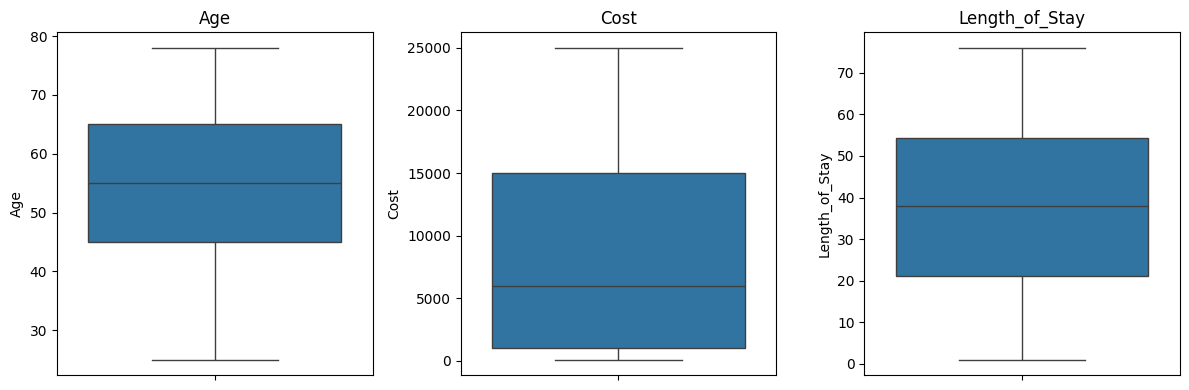

In [ ]:
# Построим боксплот для визуализации распределения значений (в частности, выбросов)
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, col in zip(axes, ['Age', 'Cost', 'Length_of_Stay']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Выбросы в значениях перменных Age, Cost, Length_of_Stay отсутствуют

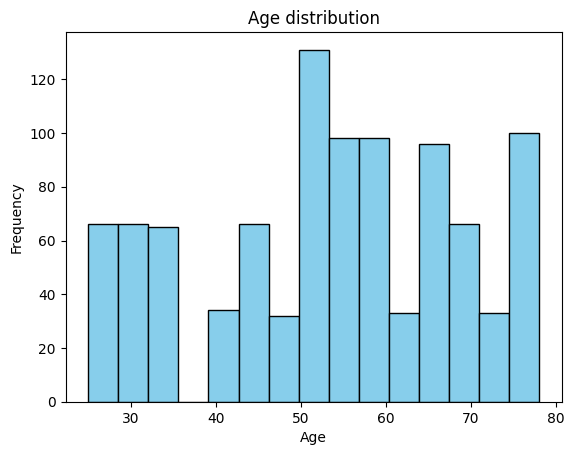

In [ ]:
plt.hist(df['Age'], bins=15, color='skyblue', edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age distribution')
plt.show()

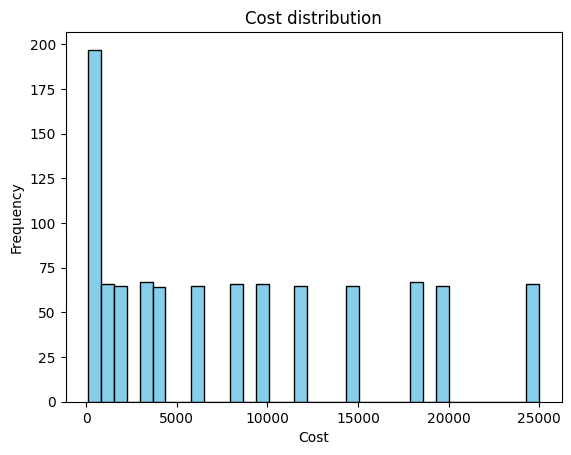

In [ ]:
plt.hist(df['Cost'], bins=35, color='skyblue', edgecolor='black')

plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.title('Cost distribution')
plt.show()

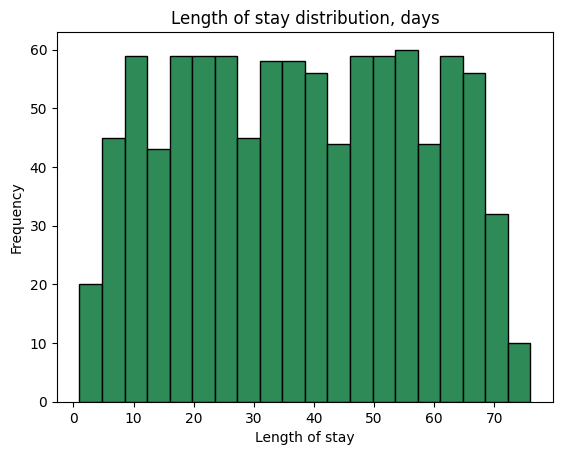

In [ ]:
plt.hist(df['Length_of_Stay'], bins=20, color='seagreen', edgecolor='black')

plt.xlabel('Length of stay')
plt.ylabel('Frequency')
plt.title('Length of stay distribution, days')
plt.show()

<Axes: ylabel='Condition'>

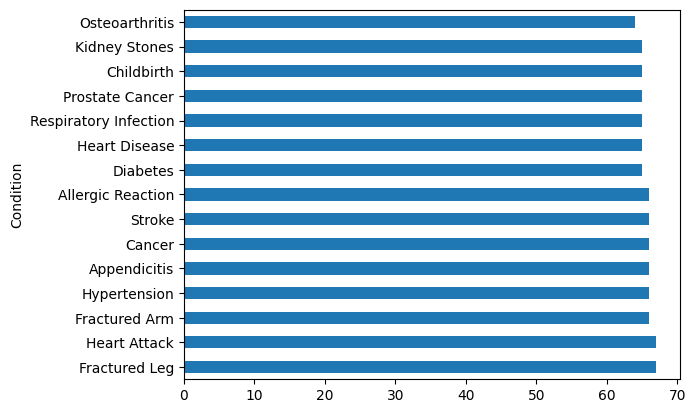

In [ ]:
df['Condition'].value_counts().plot.barh()

<Axes: ylabel='Procedure'>

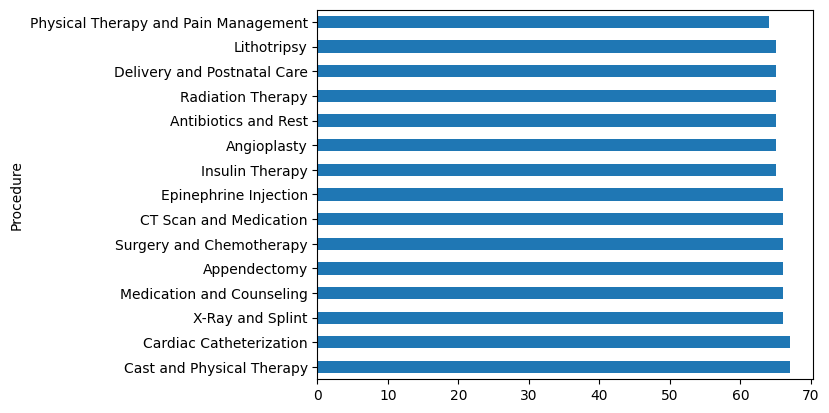

In [ ]:
df['Procedure'].value_counts().plot.barh()

Датасет содержит информацию о 984 наблюдениях и 10 признаках (5 - числовых, 5 - категориальных). Одна строка соответствует одному случаю госпитализации. Пропущенные значения и выбросы на данном этапе не обнаружены. Типы данных соответствуют смыслу переменных. Из описательной статистики исключен признак Patient_ID, как не представляющий интерес для статистической интерпретации.

Предварительно можно сделать вывод, что датасет структурно подготовлен для дальнейшего анализа.

##Поиск проблем качества данных

In [ ]:
# 1. Дубликаты по всем столбцам и по Patient_ID
print("Полные дубликаты строк:", df.duplicated().sum())
print("Дубликаты Patient_ID:", df['Patient_ID'].duplicated().sum())

Полные дубликаты строк: 0
Дубликаты Patient_ID: 0


In [ ]:
# 2. Проверка недостающих значений идентификаторов пациентов
expected_ids = set(range(df['Patient_ID'].min(), df['Patient_ID'].max() + 1))
missing_ids = sorted(expected_ids - set(df['Patient_ID']))
print("Пропущенные Patient_ID:", missing_ids)

Пропущенные Patient_ID: [60, 121, 182, 243, 295, 356, 417, 478, 539, 600, 661, 722, 784, 845, 906, 967]


In [ ]:
# 3. Связь Condition, Procedure и Cost между собой
# (Уникальных записей в каждом из этих столбцов 15)
unique_per_condition = df.groupby('Condition').agg(
    unique_procedures=('Procedure', 'nunique'),
    unique_costs=('Cost', 'nunique')
)
print(unique_per_condition)

                       unique_procedures  unique_costs
Condition                                             
Allergic Reaction                      1             1
Appendicitis                           1             1
Cancer                                 1             1
Childbirth                             1             1
Diabetes                               1             1
Fractured Arm                          1             1
Fractured Leg                          1             1
Heart Attack                           1             1
Heart Disease                          1             1
Hypertension                           1             1
Kidney Stones                          1             1
Osteoarthritis                         1             1
Prostate Cancer                        1             1
Respiratory Infection                  1             1
Stroke                                 1             1


Cost и Procedure не индивидуальны для пациента, а жестко привязаны к диагнозу (вероятно, справочные значения)

##Подготовка к изменениям

In [ ]:
 #1. Копия датафрейма для последующих изменений
df_prep = df.copy()

In [ ]:
#2. Приведение названий столбцов к нижнему регистру
df_prep.columns = df_prep.columns.str.lower()

In [ ]:
#3. Замена всех столбцов с типом object на category
object_cols = df_prep.select_dtypes(include='object').columns
df_prep[object_cols] = df_prep[object_cols].astype('category')

In [ ]:
#4. Замена типа столбца cost на float64
df_prep['cost'] = df_prep['cost'].astype('float64')

In [ ]:
#5. Проверка после изменений
print(df_prep.head())

print(df_prep.info())

   patient_id  age  gender      condition                 procedure     cost  \
0           1   45  Female  Heart Disease               Angioplasty  15000.0   
1           2   60    Male       Diabetes           Insulin Therapy   2000.0   
2           3   32  Female  Fractured Arm          X-Ray and Splint    500.0   
3           4   75    Male         Stroke    CT Scan and Medication  10000.0   
4           5   50  Female         Cancer  Surgery and Chemotherapy  25000.0   

   length_of_stay readmission    outcome  satisfaction  
0               5          No  Recovered             4  
1               3         Yes     Stable             3  
2               1          No  Recovered             5  
3               7         Yes     Stable             2  
4              10          No  Recovered             4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          -----

##Трансформации

In [ ]:
# 1. Создание дополнительного категориального признака Age_Group
df_prep['age_group'] = pd.cut(
    df_prep['age'],
    bins=[24, 34, 44, 54, 64, 100],
    labels=['25–34', '35–44', '45–54', '55–64', '65+']
)

Создан дополнительный категориальный признак Age_Group, разделяющий пациентов на возрастные группы для проверки гипотезы о наличии различий в стоимости лечения между пациентами разных возрастных диапазонов.

In [ ]:
# 2. Создание числового признака переменной Readmission
df_prep['readmission_flag'] = df_prep['readmission'].map({
    'No': 0,
    'Yes': 1
})

Создан числовой признак переменной Readmission (повторная госпитализация) для упрощения дальнейших расчётов и построения статистических моделей.

In [ ]:
# 3. Создание числового признака стоимости одного дня госпитализации
df_prep['cost_per_day'] = df_prep['cost'] / df_prep['length_of_stay']

Признак cost_per_day необходим для дальнейших рассчётов с учётом необходимости рекомендаций по оптимизации.

In [ ]:
print(df_prep[['age_group', 'readmission_flag', 'cost_per_day']].isna().sum())

age_group           0
readmission_flag    0
cost_per_day        0
dtype: int64



После создания age_group, readmission_flag, cost_per_day не возникли NaN.

In [ ]:
df_prep.head()

,patient_id,age,gender,condition,procedure,cost,length_of_stay,readmission,outcome,satisfaction,age_group,readmission_flag,cost_per_day
0,1,45,Female,Heart Disease,Angioplasty,15000.0,5,No,Recovered,4,45–54,0,3000.000000
1,2,60,Male,Diabetes,Insulin Therapy,2000.0,3,Yes,Stable,3,55–64,1,666.666667
2,3,32,Female,Fractured Arm,X-Ray and Splint,500.0,1,No,Recovered,5,25–34,0,500.000000
3,4,75,Male,Stroke,CT Scan and Medication,10000.0,7,Yes,Stable,2,65+,1,1428.571429
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000.0,10,No,Recovered,4,45–54,0,2500.000000


In [ ]:
# Сохраним обработанный датасет в csv
df_prep.to_csv('hospital_data_prepared.csv', index=False)